1. Project Introduction

Project: Customer Churn Prediction

Customer churn is an important business problem for subscription-based companies because retaining existing customers can be more cost-effective than acquiring new ones. This project aims to use customer demographic information, account characteristics, and service usage to predict which customers are most likely to churn.

The objective of this analysis is to understand the data, identify potential relationships between customer characteristics and churn, and prepare the dataset for feature engineering and machine learning.

Business Question:

Can customer demographic, account, and service information be used to predict which customers are most likely to churn?

2. Import Libraries

In [4]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

In [5]:
import os
print("Working directory:", os.getcwd())
print("Contents:", os.listdir())

Working directory: c:\Users\kedha\OneDrive\Desktop\Documents\Springboard\Case Studies\Capstone Three
Contents: ['01_data_understanding.ipynb (Capstone Three).ipynb', '02_feature_engineering.ipynb (Capstone Three).ipynb', '03_modeling.ipynb (Capstone Three).ipynb', '04_evaluation.ipynb (Capstone Three).ipynb', 'Capstone 3 - Data Wrangling.ipynb', 'Capstone 3 - EDA.ipynb', 'Capstone 3 - Pre-Processing and Modeling (2).ipynb', 'Capstone 3 - Pre-Processing and Modeling.ipynb', 'Customer Churn Prediction Silde Deck.pptx', 'Customer Churn Project Report.docx', 'data', 'Model Metrics.txt', 'Telco_Churn_Training.csv']


3. Load the Dataset

3.1 Locate the Dataset

In [6]:
df = pd.read_csv("data/WA_Fn-UseC_-Telco-Customer-Churn.csv")

3.2 Initial Dataset Preview

In [7]:
print(df.shape)

(7043, 21)


In [3]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
df.tail()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes
7042,3186-AJIEK,Male,0,No,No,66,Yes,No,Fiber optic,Yes,...,Yes,Yes,Yes,Yes,Two year,Yes,Bank transfer (automatic),105.65,6844.5,No


In [5]:
df.shape

(7043, 21)

The dataset contains customer-level records with demographic, account, and service-related information. The target variable, Churn, indicates whether a customer left the company.

4. Understand the Dataset Structure

4.1 Dataset Dimensions

In [6]:
print(f"Number of rows: {df.shape[0]}")
print(f"Number of columns: {df.shape[1]}")

Number of rows: 7043
Number of columns: 21


4.2 Column Names

In [7]:
df.columns.tolist()

['customerID',
 'gender',
 'SeniorCitizen',
 'Partner',
 'Dependents',
 'tenure',
 'PhoneService',
 'MultipleLines',
 'InternetService',
 'OnlineSecurity',
 'OnlineBackup',
 'DeviceProtection',
 'TechSupport',
 'StreamingTV',
 'StreamingMovies',
 'Contract',
 'PaperlessBilling',
 'PaymentMethod',
 'MonthlyCharges',
 'TotalCharges',
 'Churn']

4.3 Data Types

In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

4.4 Unique Values

In [9]:
for column in df.columns:
    print(f"\n{column}")
    print(df[column].unique()[:10])


customerID
<StringArray>
['7590-VHVEG', '5575-GNVDE', '3668-QPYBK', '7795-CFOCW', '9237-HQITU',
 '9305-CDSKC', '1452-KIOVK', '6713-OKOMC', '7892-POOKP', '6388-TABGU']
Length: 10, dtype: str

gender
<StringArray>
['Female', 'Male']
Length: 2, dtype: str

SeniorCitizen
[0 1]

Partner
<StringArray>
['Yes', 'No']
Length: 2, dtype: str

Dependents
<StringArray>
['No', 'Yes']
Length: 2, dtype: str

tenure
[ 1 34  2 45  8 22 10 28 62 13]

PhoneService
<StringArray>
['No', 'Yes']
Length: 2, dtype: str

MultipleLines
<StringArray>
['No phone service', 'No', 'Yes']
Length: 3, dtype: str

InternetService
<StringArray>
['DSL', 'Fiber optic', 'No']
Length: 3, dtype: str

OnlineSecurity
<StringArray>
['No', 'Yes', 'No internet service']
Length: 3, dtype: str

OnlineBackup
<StringArray>
['Yes', 'No', 'No internet service']
Length: 3, dtype: str

DeviceProtection
<StringArray>
['No', 'Yes', 'No internet service']
Length: 3, dtype: str

TechSupport
<StringArray>
['No', 'Yes', 'No internet service']
Le

5. Data Quality Assessment

5.1 Missing Values

In [10]:
missing_values = df.isnull().sum()

missing_values[missing_values > 0]

Series([], dtype: int64)

In [11]:
missing_percentage = (df.isnull().sum() / len(df)) * 100

missing_summary = pd.DataFrame({
    "Missing Values": df.isnull().sum(),
    "Percentage Missing": missing_percentage
})

missing_summary[missing_summary["Missing Values"] > 0]

,Missing Values,Percentage Missing


6. Duplicate Records

In [12]:
df.duplicated().sum()

np.int64(0)

In [13]:
df[df.duplicated()]

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn


7. Identify Potential Data Issues

7.1 Customer ID

In [14]:
df["customerID"].nunique()

7043

In [15]:
len(df)

7043

8. Numerical Variables

In [16]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


9. Categorical Variables

In [17]:
categorical_columns = df.select_dtypes(include="object").columns

categorical_columns

C:\Users\kedha\AppData\Local\Temp\ipykernel_16372\1797605437.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_columns = df.select_dtypes(include="object").columns


Index(['customerID', 'gender', 'Partner', 'Dependents', 'PhoneService',
       'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup',
       'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
       'Contract', 'PaperlessBilling', 'PaymentMethod', 'TotalCharges',
       'Churn'],
      dtype='str')

In [18]:
for column in categorical_columns:
    print(f"\n{column}")
    print(df[column].value_counts())


customerID
customerID
7590-VHVEG    1
5575-GNVDE    1
3668-QPYBK    1
7795-CFOCW    1
9237-HQITU    1
             ..
6840-RESVB    1
2234-XADUH    1
4801-JZAZL    1
8361-LTMKD    1
3186-AJIEK    1
Name: count, Length: 7043, dtype: int64

gender
gender
Male      3555
Female    3488
Name: count, dtype: int64

Partner
Partner
No     3641
Yes    3402
Name: count, dtype: int64

Dependents
Dependents
No     4933
Yes    2110
Name: count, dtype: int64

PhoneService
PhoneService
Yes    6361
No      682
Name: count, dtype: int64

MultipleLines
MultipleLines
No                  3390
Yes                 2971
No phone service     682
Name: count, dtype: int64

InternetService
InternetService
Fiber optic    3096
DSL            2421
No             1526
Name: count, dtype: int64

OnlineSecurity
OnlineSecurity
No                     3498
Yes                    2019
No internet service    1526
Name: count, dtype: int64

OnlineBackup
OnlineBackup
No                     3088
Yes                    2429


10. Target Variable: Churn

10.1 Churn Distribution

In [19]:
df["Churn"].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

In [20]:
df["Churn"].value_counts(normalize=True) * 100

Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64

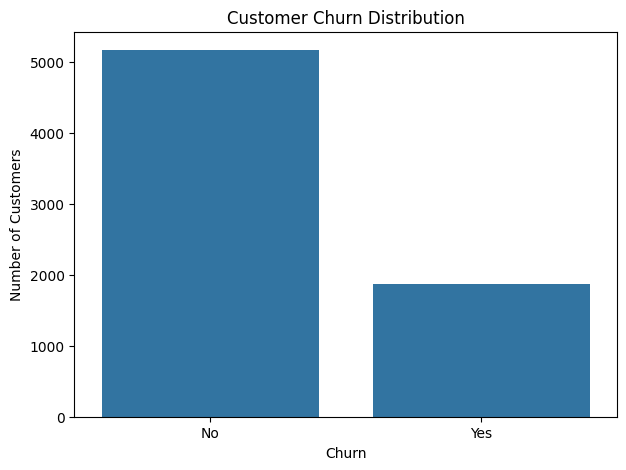

In [21]:
plt.figure(figsize=(7, 5))

sns.countplot(data=df, x="Churn")

plt.title("Customer Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")

plt.show()

The target variable is imbalanced because customers who remain with the company represent a larger proportion of the dataset than customers who churn. This imbalance should be considered when evaluating machine-learning models.

11. Exploratory Data Analysis

11.1 Demographic Factors

In [22]:
pd.crosstab(df["gender"], df["Churn"], normalize="index") * 100

Churn,No,Yes
gender,,
Female,73.079128,26.920872
Male,73.839662,26.160338


Churn Rate by Senior Citizen Status

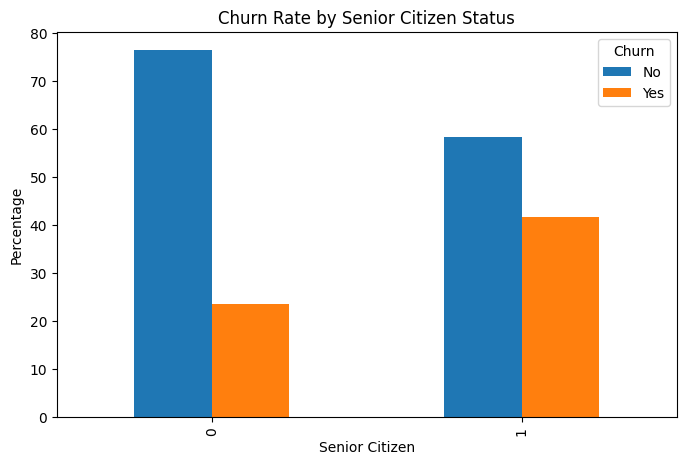

In [23]:
churn_by_senior = pd.crosstab(
    df["SeniorCitizen"],
    df["Churn"],
    normalize="index"
) * 100

churn_by_senior.plot(
    kind="bar",
    stacked=False,
    figsize=(8, 5)
)

plt.title("Churn Rate by Senior Citizen Status")
plt.xlabel("Senior Citizen")
plt.ylabel("Percentage")
plt.legend(title="Churn")

plt.show()

11.2 Account Factors

Churn by Contract

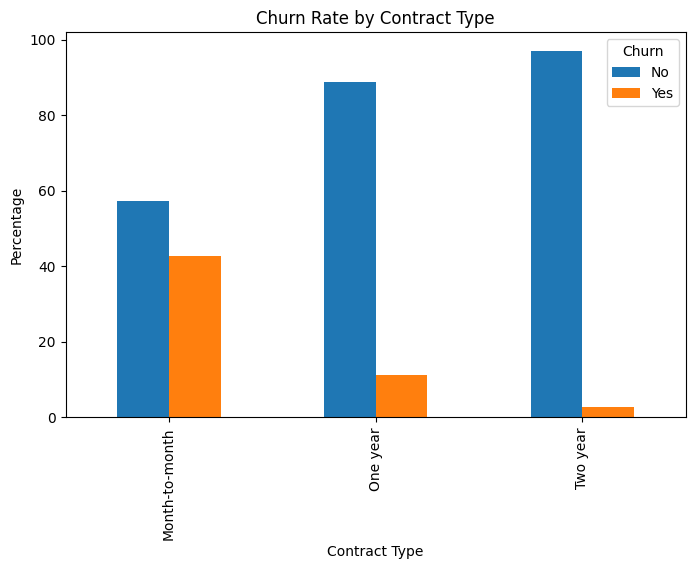

In [24]:
contract_churn = pd.crosstab(
    df["Contract"],
    df["Churn"],
    normalize="index"
) * 100

contract_churn.plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Churn Rate by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Percentage")

plt.show()

11.3 Service Factors

Investigate:

Internet Service

Online Security

Online Backup

Device Protection

Tech Support

Streaming TV

Streaming Movies

Key question:

Are particular services associated with higher or lower churn rates?

12. Numerical Variables vs. Churn

Tenure

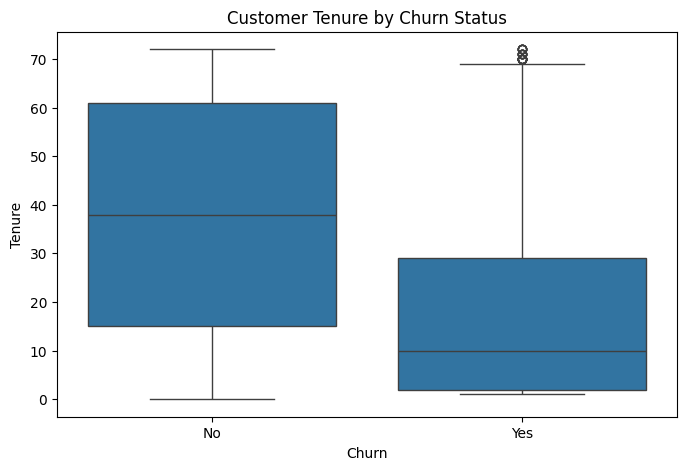

In [25]:
plt.figure(figsize=(8, 5))

sns.boxplot(data=df, x="Churn", y="tenure")

plt.title("Customer Tenure by Churn Status")
plt.xlabel("Churn")
plt.ylabel("Tenure")

plt.show()

Monthly Charges

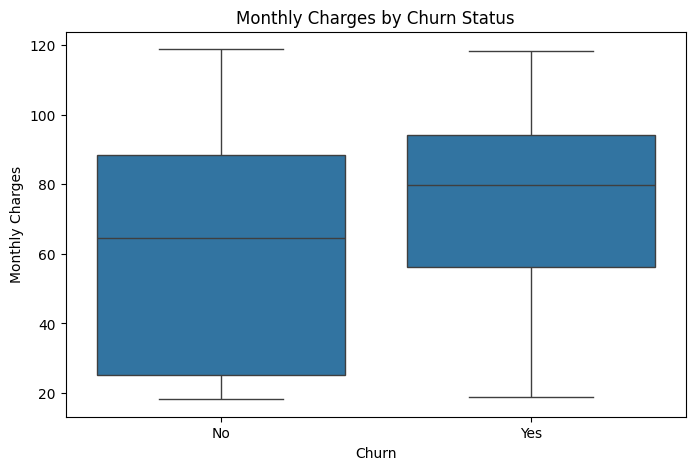

In [26]:
plt.figure(figsize=(8, 5))

sns.boxplot(data=df, x="Churn", y="MonthlyCharges")

plt.title("Monthly Charges by Churn Status")
plt.xlabel("Churn")
plt.ylabel("Monthly Charges")

plt.show()

Total Charges

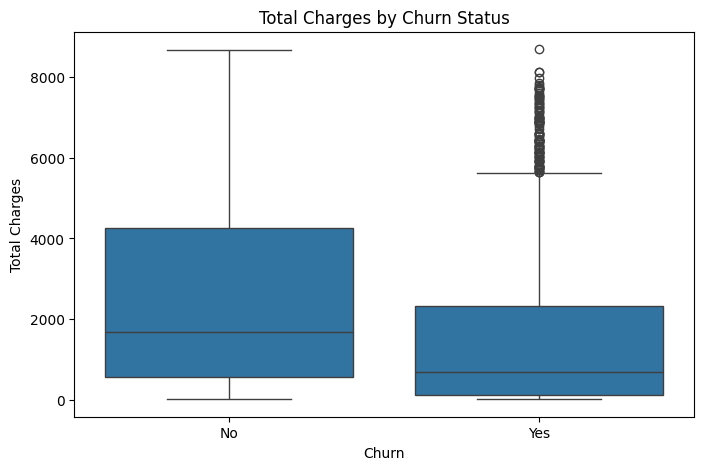

In [27]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")


plt.figure(figsize=(8, 5))

sns.boxplot(data=df, x="Churn", y="TotalCharges")

plt.title("Total Charges by Churn Status")
plt.xlabel("Churn")
plt.ylabel("Total Charges")

plt.show()

13. Initial Findings

13.1 Key EDA Findings

The exploratory analysis of customer tenure, monthly charges, and total charges reveals several notable differences between customers who remained with the company and those who churned.

Customer tenure is strongly associated with churn. Customers who churned generally had much shorter tenures than customers who remained with the company. The median tenure for customers who churned is approximately 10 months, compared with approximately 38 months for customers who did not churn. This suggests that newer customers may represent an important group for customer-retention efforts.

Customers who churned generally had higher monthly charges. The median monthly charge for customers who churned is approximately $80, compared with approximately $65 for customers who remained. This indicates that customers with higher monthly costs may be more likely to leave the company, although additional analysis is needed to determine whether monthly charges independently influence churn.

Total charges are generally lower among customers who churned. The lower total charges among churned customers are consistent with their shorter average tenure. Because total charges accumulate over the length of a customer's relationship with the company, customers who leave earlier have had less time to generate cumulative charges.

The three variables appear to be interconnected. Customers who churn tend to have shorter tenures, higher monthly charges, and lower cumulative total charges. The combination of these patterns suggests that early customer experience and the perceived value of the service may be important areas to investigate further.

Further analysis is needed to determine predictive importance. While these visualizations demonstrate meaningful differences between customers who churn and those who remain, the relationships shown in the exploratory analysis do not establish causation. The next stage of the project will use feature engineering and machine learning models to determine which customer characteristics are most useful for predicting churn.

14. Data Cleaning Decisions

14.1 Data Cleaning Summary

| Issue                 | Finding             | Action                            |
| --------------------- | ------------------- | --------------------------------- |
| Missing values        | TBD                 | TBD                               |
| Duplicate records     | TBD                 | TBD                               |
| Incorrect data types  | TBD                 | TBD                               |
| Customer ID           | Unique identifier   | Remove during feature engineering |
| Categorical variables | Multiple categories | Encode in Notebook 02             |


15. Prepare for Feature Engineering

15.1 Next Steps

The exploratory analysis provided an understanding of the customer population and identified several variables that may be associated with churn. The next step is to prepare these variables for machine learning. This will include addressing remaining data-quality issues, encoding categorical variables, separating the target variable, splitting the data into training and testing sets, and standardizing numerical features.